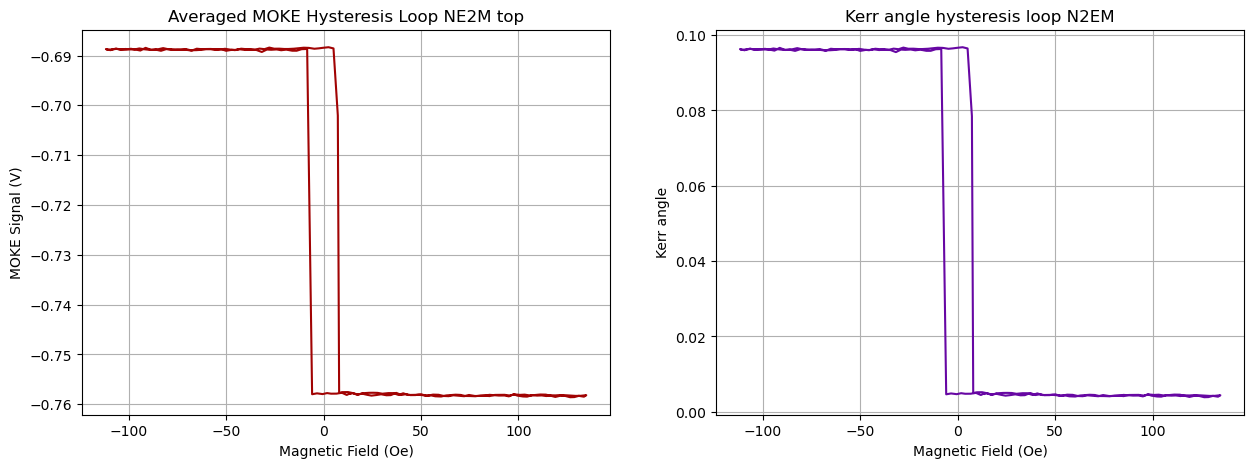

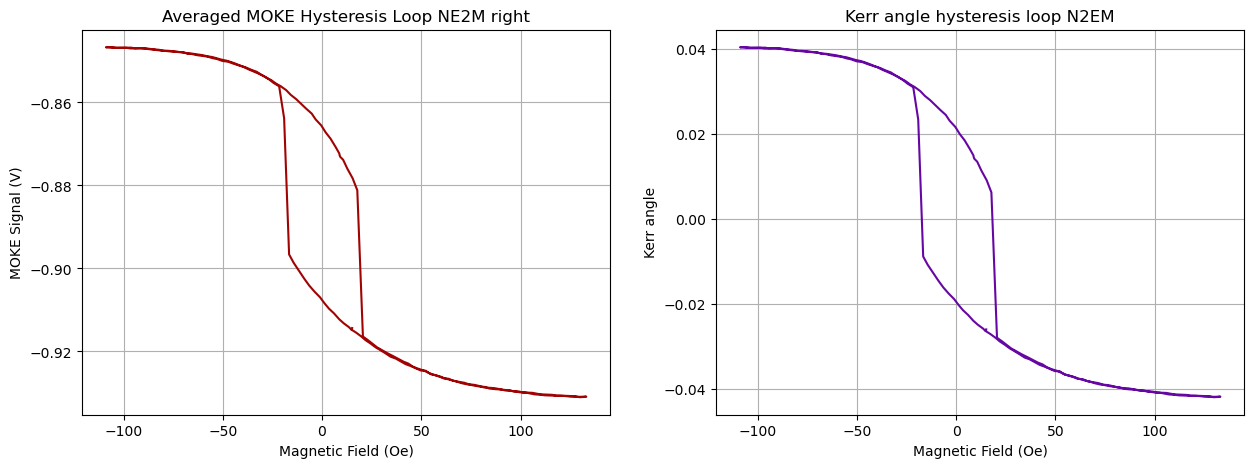

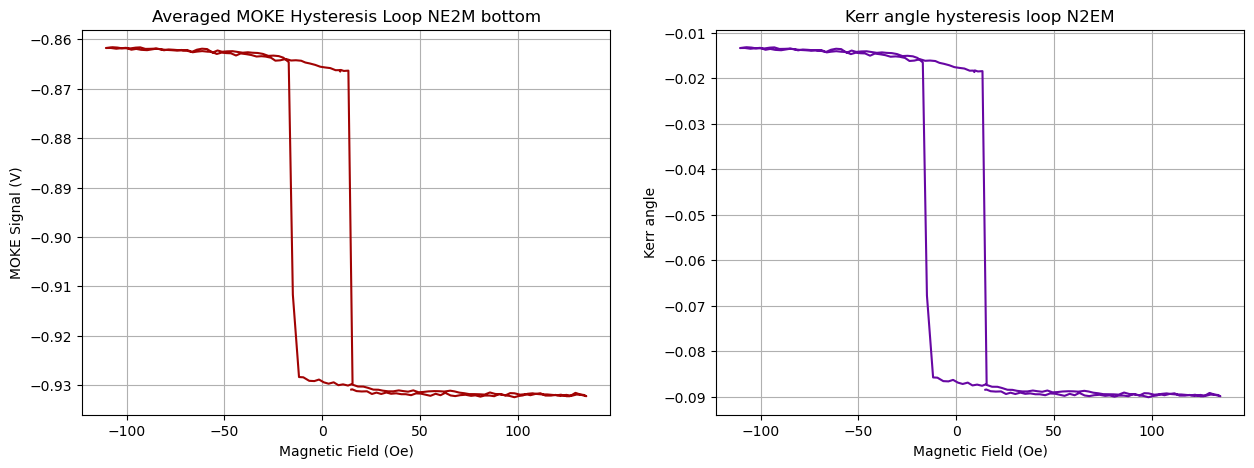

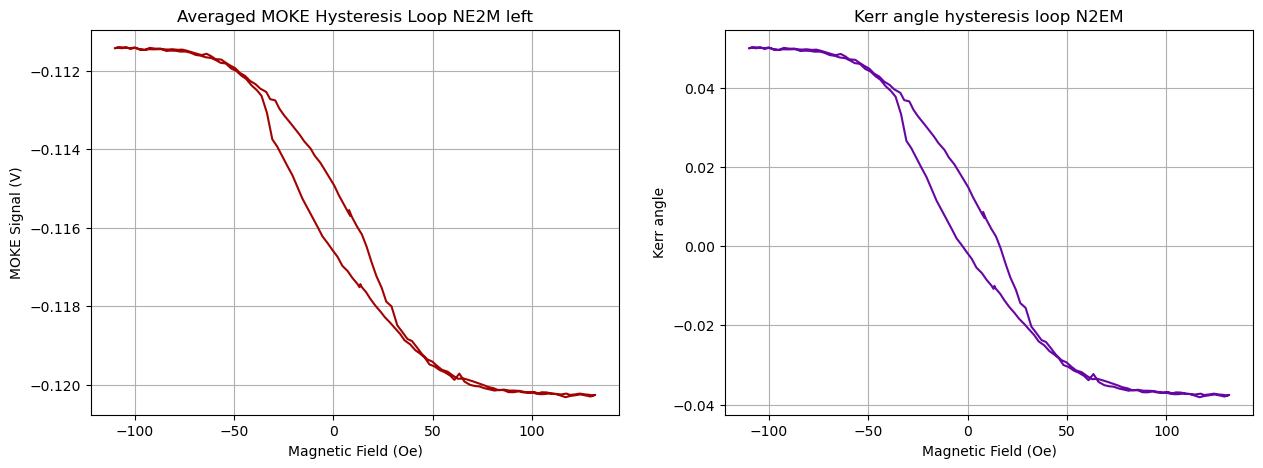

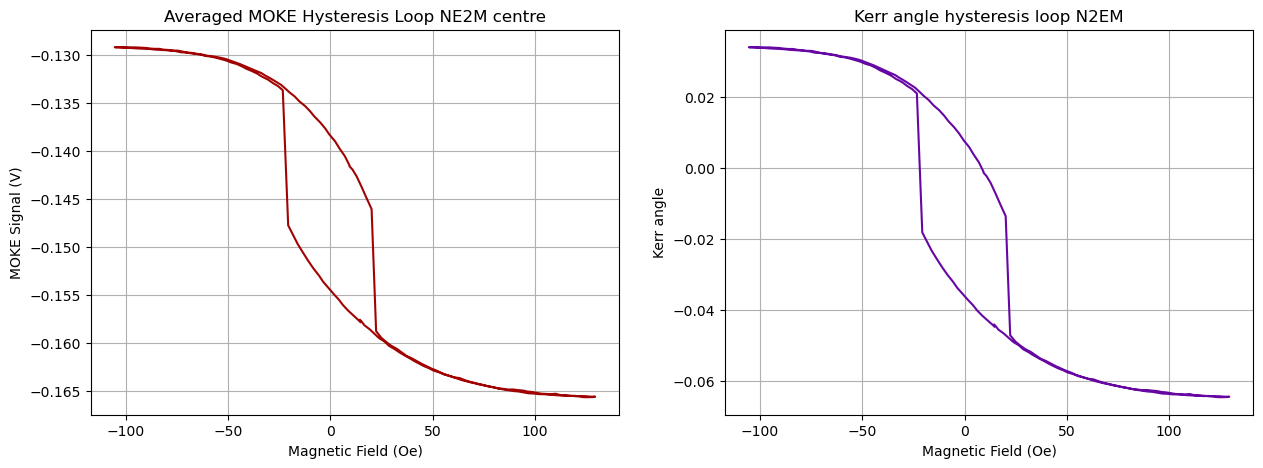

In [1]:
'''
author: amir kamalian
date: 11 may 2026

NE2M MOKE analysis
'''

import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 

# headers: time(ms),field(Oe),signal(V),angle,step
centre = pd.read_csv('../../MOKE-raw-data/2026_MAY_13-GdCo_Lily_NE2M_G1.csv')
left = pd.read_csv('../../MOKE-raw-data/2026_MAY_14-GdCo_Lily_NE2M_G2.csv')
right = pd.read_csv('../../MOKE-raw-data/2026_MAY_14-GdCo_Lily_NE2M_G3.csv')
top = pd.read_csv('../../MOKE-raw-data/2026_MAY_19-GdCo_Lily_NE2M_G4.csv')
bottom = pd.read_csv('../../MOKE-raw-data/2026_MAY_19-GdCo_Lily_NE2M_G5.csv')

df = [top, right, bottom, left, centre]
titles = ["top", "right", "bottom", "left", "centre"]
n = 0

''' 
we must take the average of each of the polarities
'''
for G in df:
    # separating the cycles by steps 
    G["cycle"] = (G["step"].diff() < 0).cumsum()
    
    # separating polarities 
    even_polarity = G[G["cycle"] % 2 == 0]
    odd_polarity = G[G["cycle"] % 2 == 1]
    
    # averaging the respective polarities 
    evenp_avg = even_polarity.groupby("step").aggregate({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean"
    })
    
    oddp_avg = odd_polarity.groupby("step").aggregate({
        "field(Oe)" : "mean",
        "signal(V)" : "mean",
        "angle" : "mean"
    })
    
    
    # combining results
    df_final = pd.concat([evenp_avg, oddp_avg], axis=0)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios" : [1,1]})
    
    # ax1: applied field vs signal 
    ax1.plot(df_final["field(Oe)"], df_final["signal(V)"], color="#a10303")
    
    ax1.set_xlabel("Magnetic Field (Oe)")
    ax1.set_ylabel("MOKE Signal (V)")
    ax1.set_title("Averaged MOKE Hysteresis Loop NE2M " + titles[n])
    ax1.grid()
    n+=1
    
    # ax2: applied field vs kerr angle 
    ax2.plot(df_final["field(Oe)"], -df_final["angle"], color="#6707a3")
    
    ax2.set_xlabel("Magnetic Field (Oe)")
    ax2.set_ylabel("Kerr angle")
    ax2.set_title("Kerr angle hysteresis loop N2EM")
    ax2.grid()


plt.show()


